In [1]:
import sys

print(sys.executable)

c:\Users\NV\OneDrive\Desktop\house-price-project\.venv\Scripts\python.exe


# House Price Prediction

# 1. Load and Inspect the Dataset

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("notebooks\data\house_prices.csv")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
C:\Users\NV\AppData\Local\Temp\ipykernel_8776\3888636231.py:1: SyntaxWarning: invalid escape sequence '\d'
  df = pd.read_csv("notebooks\data\house_prices.csv")


In [6]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [7]:
df.shape

(187531, 21)

In [8]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [9]:
df.describe()

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


In [10]:
df.isna().sum().sort_values(ascending=False)

Plot Area            187531
Dimensions           187531
Society              109678
Super Area           107685
Car Parking          103357
overlooking           81436
Carpet Area           80673
facing                70233
Ownership             65517
Balcony               48935
Price (in rupees)     17665
Floor                  7077
Description            3023
Furnishing             2897
Bathroom                828
Status                  615
Transaction              83
Amount(in rupees)         0
Title                     0
Index                     0
location                  0
dtype: int64

# 2. Exploratory Data Analysis (EDA)

# 2.1 Price Analysis

In [11]:
import re

In [12]:
def parse_amount(x):
    if pd.isna(x):
        return np.nan

    x = str(x).strip().lower()

    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 100000

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 10000000

        return float(x.replace(",", ""))

    except ValueError:
        return np.nan

In [13]:
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

In [14]:
df[["Amount(in rupees)", "price_clean"]].head(10)

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [15]:
df["price_clean"].isna().sum()

np.int64(9684)

In [16]:
df = df.dropna(subset=["price_clean"]).copy()

In [17]:
df.shape

(177847, 22)

In [18]:
df["price_clean"].isna().sum()

np.int64(0)

In [19]:
df["price_clean"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64

# 2.2 Price Distribution

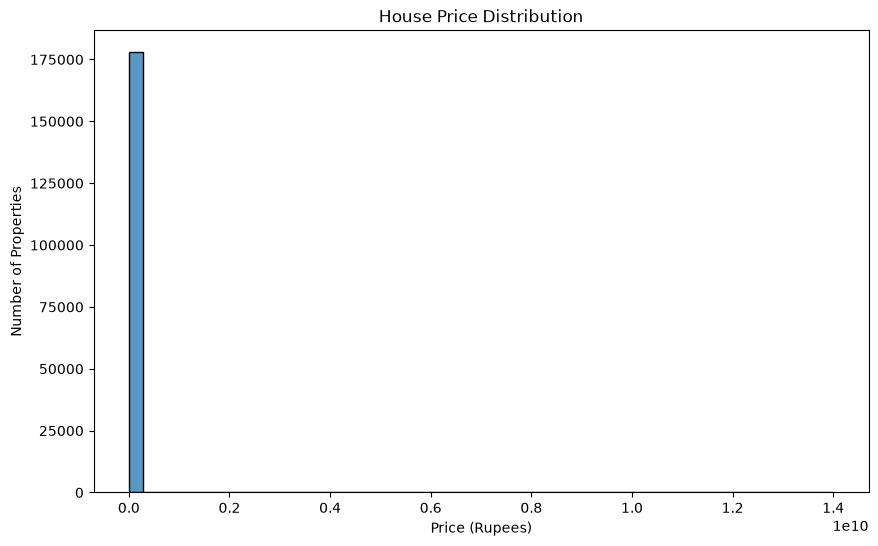

In [20]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["price_clean"],
    bins=50
)

plt.title("House Price Distribution")
plt.xlabel("Price (Rupees)")
plt.ylabel("Number of Properties")

plt.show()

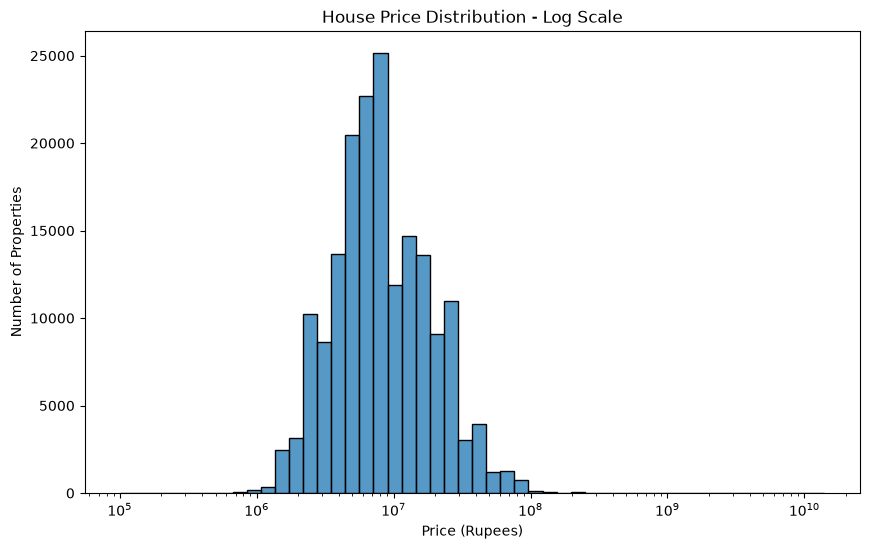

In [21]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df["price_clean"],
    bins=50,
    log_scale=True
)

plt.title("House Price Distribution - Log Scale")
plt.xlabel("Price (Rupees)")
plt.ylabel("Number of Properties")

plt.show()

In [22]:
df["Carpet Area"].head(20)

0      500 sqft
1      473 sqft
2      779 sqft
3      530 sqft
4      635 sqft
5           NaN
6      550 sqft
7           NaN
8           NaN
9      900 sqft
10     950 sqft
11          NaN
12          NaN
13    1820 sqft
14          NaN
15     675 sqft
16     647 sqft
17          NaN
18     600 sqft
19          NaN
Name: Carpet Area, dtype: str

In [23]:
def parse_carpet_area(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).lower().strip()
    
    numbers = re.findall(r"\d+(?:\.\d+)?", x)
    
    if numbers:
        return float(numbers[0])
    
    return np.nan

In [24]:
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_carpet_area)

In [25]:
df[["Carpet Area", "carpet_area_sqft"]].head(20)

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


In [26]:
df["carpet_area_sqft"].isna().sum()

np.int64(76325)

In [27]:
df["carpet_area_sqft"].describe()

count    101522.000000
mean       1226.384912
std        3119.368046
min           1.000000
25%         770.250000
50%        1050.000000
75%        1500.000000
max      709222.000000
Name: carpet_area_sqft, dtype: float64

In [28]:
lower_area = df["carpet_area_sqft"].quantile(0.01)
upper_area = df["carpet_area_sqft"].quantile(0.99)

print("1st percentile:", lower_area)
print("99th percentile:", upper_area)

1st percentile: 50.0
99th percentile: 4583.0


In [29]:
df["carpet_area_sqft"] = df["carpet_area_sqft"].where(
    df["carpet_area_sqft"].between(lower_area, upper_area),
    np.nan
)

In [30]:
df["carpet_area_sqft"].describe()

count    100925.00000
mean       1181.86810
std         688.78948
min          50.00000
25%         770.00000
50%        1050.00000
75%        1500.00000
max        4583.00000
Name: carpet_area_sqft, dtype: float64

In [31]:
df["carpet_area_sqft"].isna().sum()

np.int64(76922)

In [32]:
plot_df = df[
    df["carpet_area_sqft"].notna() &
    df["price_clean"].notna()
].copy()

print("Rows available for plot:", len(plot_df))

Rows available for plot: 100925


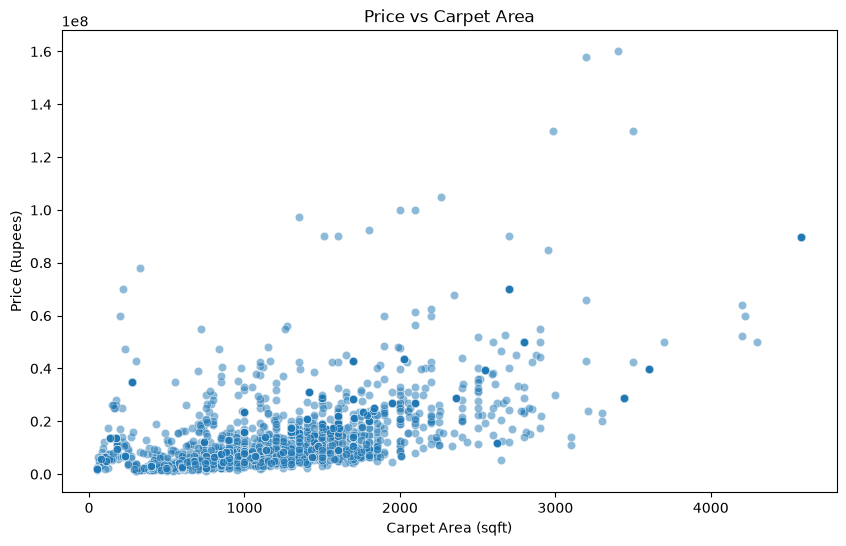

In [33]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=plot_df.sample(min(5000, len(plot_df)), random_state=42),
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.5
)

plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (Rupees)")

plt.show()

In [34]:
df["Floor"].head(20)

0        10 out of 11
1         3 out of 22
2        10 out of 29
3          1 out of 3
4        20 out of 42
5          2 out of 7
6          4 out of 5
7     Ground out of 7
8     Ground out of 2
9         3 out of 27
10        6 out of 20
11       16 out of 24
12        8 out of 20
13       18 out of 27
14         2 out of 3
15       10 out of 16
16         5 out of 7
17         4 out of 5
18       20 out of 28
19         3 out of 3
Name: Floor, dtype: str

In [35]:
def parse_floor(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x).strip().lower()
    
    if "ground" in x:
        return 0
    
    numbers = re.findall(r"\d+", x)
    
    if numbers:
        return float(numbers[0])
    
    return np.nan

In [36]:
df["floor_num"] = df["Floor"].apply(parse_floor)

In [37]:
df[["Floor", "floor_num"]].head(20)

,Floor,floor_num
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0
5,2 out of 7,2.0
6,4 out of 5,4.0
7,Ground out of 7,0.0
8,Ground out of 2,0.0
9,3 out of 27,3.0


In [38]:
df["floor_num"].isna().sum()

np.int64(6950)

In [39]:
df["floor_num"].describe()

count    170897.000000
mean          4.515404
std           4.703230
min           0.000000
25%           2.000000
50%           3.000000
75%           6.000000
max         200.000000
Name: floor_num, dtype: float64

In [40]:
lower_floor = df["floor_num"].quantile(0.01)
upper_floor = df["floor_num"].quantile(0.99)

print("1st percentile:", lower_floor)
print("99th percentile:", upper_floor)

1st percentile: 0.0
99th percentile: 21.0


In [41]:
df["floor_num"] = df["floor_num"].where(
    df["floor_num"].between(lower_floor, upper_floor),
    np.nan
)

In [43]:
df["floor_num"].describe()


count    169440.000000
mean          4.300012
std           4.054544
min           0.000000
25%           2.000000
50%           3.000000
75%           6.000000
max          21.000000
Name: floor_num, dtype: float64

In [44]:
df["floor_num"].isna().sum()

np.int64(8407)

In [45]:
df["Bathroom"].head(20)

0     1
1     2
2     2
3     1
4     2
5     1
6     1
7     1
8     1
9     3
10    2
11    2
12    2
13    4
14    1
15    2
16    1
17    1
18    2
19    1
Name: Bathroom, dtype: str

In [46]:
df["bathroom"] = pd.to_numeric(
    df["Bathroom"],
    errors="coerce"
)

In [47]:
df[["Bathroom", "bathroom"]].head(20)

,Bathroom,bathroom
0,1,1.0
1,2,2.0
2,2,2.0
3,1,1.0
4,2,2.0
5,1,1.0
6,1,1.0
7,1,1.0
8,1,1.0
9,3,3.0


In [48]:
df["bathroom"].describe()

count    177058.000000
mean          2.448090
std           0.852182
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          10.000000
Name: bathroom, dtype: float64

In [49]:
df["bathroom"].isna().sum()

np.int64(789)

In [50]:
df["Balcony"].head(20)

0       2
1     NaN
2     NaN
3       1
4     NaN
5       1
6     NaN
7     NaN
8     NaN
9       1
10    NaN
11    NaN
12    NaN
13      1
14    NaN
15      1
16      2
17    NaN
18    NaN
19      1
Name: Balcony, dtype: str

In [51]:
df["balcony"] = pd.to_numeric(
    df["Balcony"],
    errors="coerce"
)

In [52]:
df[["Balcony", "balcony"]].head(20)

,Balcony,balcony
0,2,2.0
1,NaN,NaN
2,NaN,NaN
3,1,1.0
4,NaN,NaN
5,1,1.0
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,1,1.0


In [53]:
df["balcony"].describe()

count    130672.000000
mean          2.012084
std           0.951446
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max          10.000000
Name: balcony, dtype: float64

In [54]:
df["balcony"].isna().sum()

np.int64(47175)

In [55]:
df["Car Parking"].head(20)

0            NaN
1         1 Open
2      1 Covered
3            NaN
4      1 Covered
5            NaN
6            NaN
7            NaN
8            NaN
9      1 Covered
10        1 Open
11           NaN
12           NaN
13     2 Covered
14           NaN
15     1 Covered
16           NaN
17           NaN
18    66 Covered
19        1 Open
Name: Car Parking, dtype: str

In [56]:
def parse_car_parking(x):
    if pd.isna(x):
        return np.nan
    
    numbers = re.findall(r"\d+(?:\.\d+)?", str(x))
    
    if numbers:
        return float(numbers[0])
    
    return np.nan

In [57]:
df["car_parking"] = df["Car Parking"].apply(parse_car_parking)

In [58]:
df[["Car Parking", "car_parking"]].head(20)

,Car Parking,car_parking
0,NaN,NaN
1,1 Open,1.0
2,1 Covered,1.0
3,NaN,NaN
4,1 Covered,1.0
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,1 Covered,1.0


In [59]:
df["car_parking"].describe()

count    81935.000000
mean         4.006786
std         31.614264
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        999.000000
Name: car_parking, dtype: float64

In [60]:
df["car_parking"].isna().sum()

np.int64(95912)

In [61]:
lower_parking = df["car_parking"].quantile(0.01)
upper_parking = df["car_parking"].quantile(0.99)

print("1st percentile:", lower_parking)
print("99th percentile:", upper_parking)


1st percentile: 1.0
99th percentile: 34.0


In [62]:
df["car_parking"] = df["car_parking"].where(
    df["car_parking"].between(lower_parking, upper_parking),
    np.nan
)

In [63]:
df["car_parking"].describe()

count    81346.000000
mean         1.587060
std          2.994588
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         34.000000
Name: car_parking, dtype: float64

In [64]:
df["car_parking"].isna().sum()

np.int64(96501)

In [65]:
df["location"].value_counts().head(20)

location
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
vadodara          2361
surat             2180
pune              2177
thane             1869
mumbai            1814
visakhapatnam     1729
mohali            1479
zirakpur          1478
chandigarh        1402
noida             1247
Name: count, dtype: int64

In [66]:
df["location"].nunique()

81

In [67]:
top_locations = (
    df["location"]
    .value_counts()
    .head(50)
    .index
)

In [68]:
df["location_grouped"] = df["location"].where(
    df["location"].isin(top_locations),
    "Other"
)

In [69]:
df["location_grouped"].value_counts().head(55)

location_grouped
new-delhi        24945
bangalore        23262
kolkata          21605
gurgaon          18846
ahmedabad        12614
hyderabad        11147
chennai          10163
jaipur            7867
greater-noida     4490
faridabad         3733
Other             2992
vadodara          2361
surat             2180
pune              2177
thane             1869
mumbai            1814
visakhapatnam     1729
mohali            1479
zirakpur          1478
chandigarh        1402
noida             1247
goa               1153
ranchi            1065
bhiwadi           1035
kochi             1029
dehradun           948
ghaziabad          895
lucknow            816
patna              771
kanpur             761
guwahati           750
sonipat            748
navi-mumbai        691
nagpur             626
jamshedpur         622
kalyan             594
coimbatore         586
vijayawada         552
palghar            496
raipur             496
aurangabad         444
agra               443
mangalore        

In [70]:
df["location_grouped"].nunique()

51

# 2.3 Average Price by Location

In [71]:
location_prices = (
    df[df["location_grouped"] != "Other"]
    .groupby("location_grouped")["price_clean"]
    .mean()
    .sort_values(ascending=False)
)

In [72]:
top_15_locations = location_prices.head(15)

In [73]:
top_15_locations

location_grouped
mumbai         3.355292e+07
gurgaon        2.170470e+07
siliguri       1.803144e+07
panchkula      1.712139e+07
raipur         1.638794e+07
new-delhi      1.616784e+07
hyderabad      1.526815e+07
chennai        1.139704e+07
noida          1.122650e+07
navi-mumbai    1.102281e+07
kochi          1.099385e+07
vadodara       1.082852e+07
pune           1.052901e+07
ahmedabad      1.027555e+07
bangalore      1.006305e+07
Name: price_clean, dtype: float64

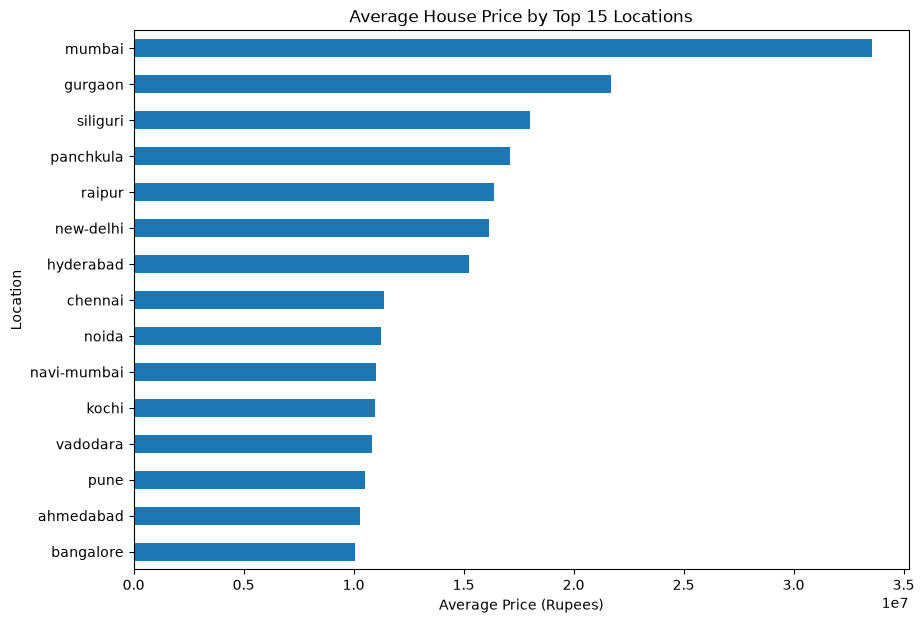

In [74]:
plt.figure(figsize=(10, 7))

top_15_locations.sort_values().plot(kind="barh")

plt.title("Average House Price by Top 15 Locations")
plt.xlabel("Average Price (Rupees)")
plt.ylabel("Location")

plt.show()

# 2.4 Price by Furnishing Status

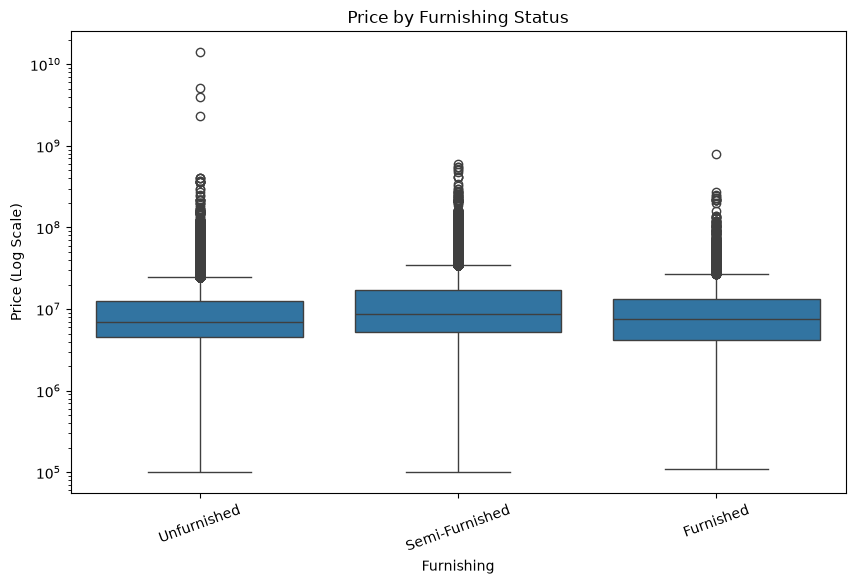

In [75]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="Furnishing",
    y="price_clean"
)

plt.yscale("log")

plt.title("Price by Furnishing Status")
plt.xlabel("Furnishing")
plt.ylabel("Price (Log Scale)")

plt.xticks(rotation=20)

plt.show()

In [76]:
features_check = [
    "carpet_area_sqft",
    "floor_num",
    "bathroom",
    "balcony",
    "car_parking",
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

df[features_check].isna().sum().sort_values(ascending=False)

car_parking         96501
carpet_area_sqft    76922
facing              65736
Ownership           61925
balcony             47175
floor_num            8407
Furnishing           2067
bathroom              789
Transaction            67
location_grouped        0
dtype: int64

# 3. Model Preparation

# 3.1 Feature Selection

In [77]:
numeric_features = [
    "carpet_area_sqft",
    "floor_num",
    "bathroom",
    "balcony",
    "car_parking"
]

categorical_features = [
    "location_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing"
]

In [78]:
X = df[
    numeric_features + categorical_features
].copy()

In [79]:
X.head()

,carpet_area_sqft,floor_num,bathroom,balcony,car_parking,location_grouped,Furnishing,Transaction,Ownership,facing
0,500.0,10.0,1.0,2.0,NaN,thane,Unfurnished,Resale,NaN,NaN
1,473.0,3.0,2.0,NaN,1.0,thane,Semi-Furnished,Resale,Freehold,East
2,779.0,10.0,2.0,NaN,1.0,thane,Unfurnished,Resale,Freehold,East
3,530.0,1.0,1.0,1.0,NaN,thane,Unfurnished,Resale,NaN,NaN
4,635.0,20.0,2.0,NaN,1.0,thane,Unfurnished,Resale,Co-operative Society,West


In [80]:
y = df["price_clean"].copy()

In [81]:
y.head()

0     4200000.0
1     9800000.0
2    14000000.0
3     2500000.0
4    16000000.0
Name: price_clean, dtype: float64

In [82]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (177847, 10)
y shape: (177847,)


In [83]:
from sklearn.model_selection import train_test_split

In [84]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [85]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (142277, 10)
X_test: (35570, 10)
y_train: (142277,)
y_test: (35570,)


In [86]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [87]:
numeric_features

['carpet_area_sqft', 'floor_num', 'bathroom', 'balcony', 'car_parking']

In [88]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [89]:
categorical_features

['location_grouped', 'Furnishing', 'Transaction', 'Ownership', 'facing']

In [90]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [91]:
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [92]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [94]:
print("X_train processed:", X_train_processed.shape)
print("X_test processed:", X_test_processed.shape)

X_train processed: (142277, 75)
X_test processed: (35570, 75)


In [95]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [96]:
linear_model = LinearRegression()

In [97]:
linear_model.fit(X_train_processed, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](75,)","[ 3735493.98, 671237.9 , 6027658.61,...,-1678435.55,-3094854.19, 2671472.28]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.231e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,75


In [98]:
y_pred_linear = linear_model.predict(X_test_processed)

In [99]:
mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression Results
-------------------------
MAE : 5374447.244189858
RMSE: 75736516.51463442
R²  : 0.0176918556304686


In [100]:
from sklearn.ensemble import RandomForestRegressor

In [101]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [102]:
rf_model.fit(X_train_processed, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [103]:
y_pred_rf = rf_model.predict(X_test_processed)

In [104]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest Results
---------------------
MAE : 1944869.3772763736
RMSE: 76497265.37209642
R²  : -0.0021411912391837706


In [105]:
from sklearn.ensemble import GradientBoostingRegressor

In [106]:
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [107]:
gb_model.fit(X_train_processed, y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [108]:
y_pred_gb = gb_model.predict(X_test_processed)

In [109]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(
    mean_squared_error(y_test, y_pred_gb)
)

r2_gb = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("-------------------------")
print("MAE :", mae_gb)
print("RMSE:", rmse_gb)
print("R²  :", r2_gb)

Gradient Boosting Results
-------------------------
MAE : 4293216.302579975
RMSE: 75574519.22368899
R²  : 0.02188959479175112


In [110]:
y_log = np.log1p(y)

In [111]:
y_log.describe()

count    177847.000000
mean         15.923140
std           0.821877
min          11.512935
25%          15.392425
50%          15.869634
75%          16.489659
max          23.362537
Name: price_clean, dtype: float64

In [113]:
y_log_train = y_log.loc[X_train.index]
y_log_test = y_log.loc[X_test.index]

In [114]:
print("y_log_train:", y_log_train.shape)
print("y_log_test:", y_log_test.shape)

y_log_train: (142277,)
y_log_test: (35570,)


In [115]:
gb_log_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [116]:
gb_log_model.fit(
    X_train_processed,
    y_log_train
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [117]:
y_pred_log = gb_log_model.predict(X_test_processed)

In [118]:
y_pred_log_price = np.expm1(y_pred_log)

In [119]:
mae_gb_log = mean_absolute_error(
    y_test,
    y_pred_log_price
)

rmse_gb_log = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_log_price
    )
)

r2_gb_log = r2_score(
    y_test,
    y_pred_log_price
)

print("Gradient Boosting - Log Target")
print("--------------------------------")
print("MAE :", mae_gb_log)
print("RMSE:", rmse_gb_log)
print("R²  :", r2_gb_log)

Gradient Boosting - Log Target
--------------------------------
MAE : 4133966.87911417
RMSE: 75727999.27304336
R²  : 0.017912781696805657


In [120]:
y.quantile([0.90, 0.95, 0.99, 0.995, 0.999, 1.0])

0.900    2.400000e+07
0.950    3.390000e+07
0.990    7.000000e+07
0.995    8.960000e+07
0.999    1.250000e+08
1.000    1.400300e+10
Name: price_clean, dtype: float64

In [121]:
price_upper = y.quantile(0.999)

print("Upper price limit:", price_upper)

Upper price limit: 125000000.0


In [122]:
y_clipped = y.clip(upper=price_upper)

In [123]:
y_clipped_train = y_clipped.loc[X_train.index]
y_clipped_test = y_clipped.loc[X_test.index]

In [124]:
print(y_clipped_train.shape)
print(y_clipped_test.shape)

(142277,)
(35570,)


In [125]:
gb_clip_model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [126]:
gb_clip_model.fit(
    X_train_processed,
    y_clipped_train
)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, in

In [127]:
y_pred_clip = gb_clip_model.predict(X_test_processed)

In [128]:
mae_clip = mean_absolute_error(
    y_clipped_test,
    y_pred_clip
)

rmse_clip = np.sqrt(
    mean_squared_error(
        y_clipped_test,
        y_pred_clip
    )
)

r2_clip = r2_score(
    y_clipped_test,
    y_pred_clip
)

print("Gradient Boosting - Clipped Target")
print("----------------------------------")
print("MAE :", mae_clip)
print("RMSE:", rmse_clip)
print("R²  :", r2_clip)

Gradient Boosting - Clipped Target
----------------------------------
MAE : 3630687.154314807
RMSE: 6439263.684334941
R²  : 0.7362990642380183


In [129]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting",
        "Gradient Boosting + Log Target",
        "Gradient Boosting + Clipped Target"
    ],
    "MAE": [
        mae_linear,
        mae_rf,
        mae_gb,
        mae_gb_log,
        mae_clip
    ],
    "RMSE": [
        rmse_linear,
        rmse_rf,
        rmse_gb,
        rmse_gb_log,
        rmse_clip
    ],
    "R2": [
        r2_linear,
        r2_rf,
        r2_gb,
        r2_gb_log,
        r2_clip
    ]
})

results

,Model,MAE,RMSE,R2
0,Linear Regression,5.374447e+06,7.573652e+07,0.017692
1,Random Forest,1.944869e+06,7.649727e+07,-0.002141
2,Gradient Boosting,4.293216e+06,7.557452e+07,0.021890
3,Gradient Boosting + Log Target,4.133967e+06,7.572800e+07,0.017913
4,Gradient Boosting + Clipped Target,3.630687e+06,6.439264e+06,0.736299


In [130]:
results.sort_values(
    by="R2",
    ascending=False
)

,Model,MAE,RMSE,R2
4,Gradient Boosting + Clipped Target,3.630687e+06,6.439264e+06,0.736299
2,Gradient Boosting,4.293216e+06,7.557452e+07,0.021890
3,Gradient Boosting + Log Target,4.133967e+06,7.572800e+07,0.017913
0,Linear Regression,5.374447e+06,7.573652e+07,0.017692
1,Random Forest,1.944869e+06,7.649727e+07,-0.002141


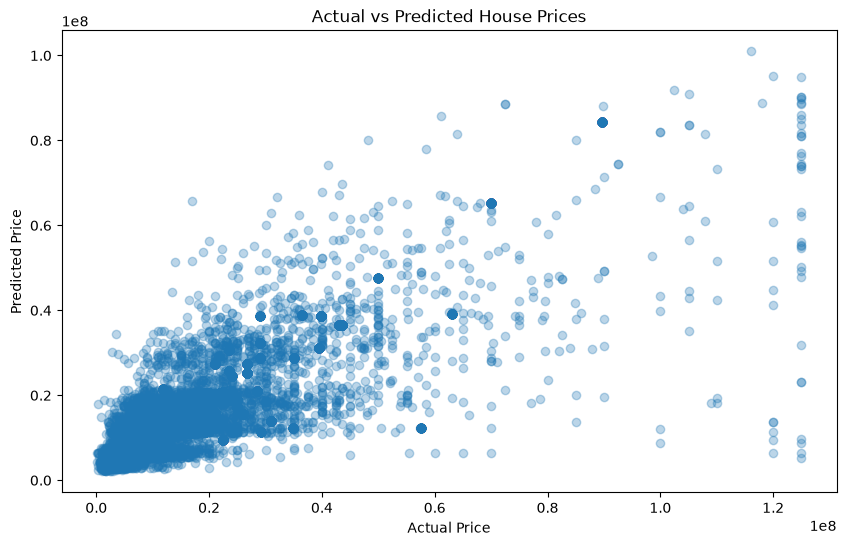

In [131]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_clipped_test,
    y_pred_clip,
    alpha=0.3
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

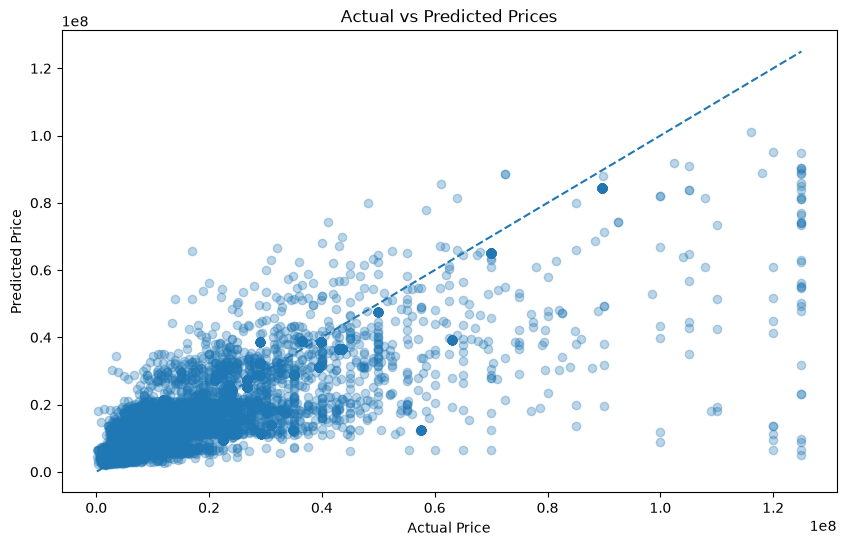

In [132]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_clipped_test,
    y_pred_clip,
    alpha=0.3
)

min_value = min(
    y_clipped_test.min(),
    y_pred_clip.min()
)

max_value = max(
    y_clipped_test.max(),
    y_pred_clip.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [133]:
feature_names = preprocessor.get_feature_names_out()

In [134]:
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": gb_clip_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
2,numeric__bathroom,0.592279
0,numeric__carpet_area_sqft,0.167986
4,numeric__car_parking,0.070643
34,categorical__location_grouped_mumbai,0.043817
38,categorical__location_grouped_new-delhi,0.041949
22,categorical__location_grouped_gurgaon,0.030549
1,numeric__floor_num,0.016637
24,categorical__location_grouped_hyderabad,0.008540
7,categorical__location_grouped_ahmedabad,0.005825
71,categorical__facing_South,0.003772


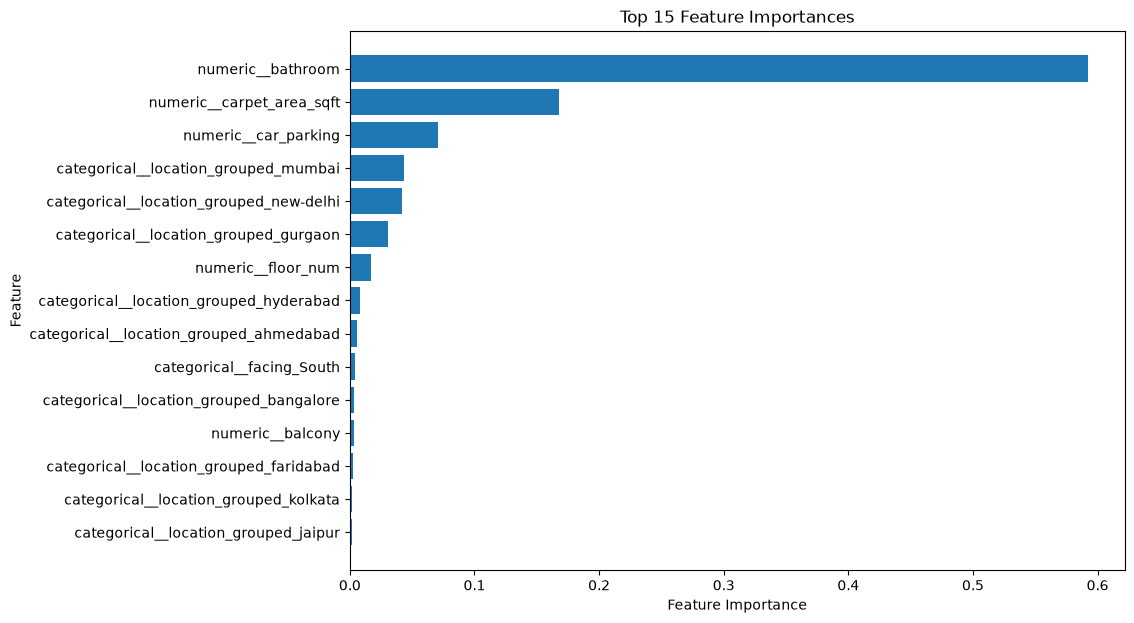

In [135]:
top_features = importance_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")

plt.show()

In [136]:
best_model_result = results.loc[
    results["R2"].idxmax()
]

best_model_result

Model    Gradient Boosting + Clipped Target
MAE                          3630687.154315
RMSE                         6439263.684335
R2                                 0.736299
Name: 4, dtype: object

In [137]:
final_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

In [138]:
final_model.fit(
    X_train,
    y_clipped_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['carpet_area_sqft','floor_num','bathroom',...,'Transaction','Ownership', 'facing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through

In [139]:
final_predictions = final_model.predict(X_test)

In [140]:
final_mae = mean_absolute_error(
    y_clipped_test,
    final_predictions
)

final_rmse = np.sqrt(
    mean_squared_error(
        y_clipped_test,
        final_predictions
    )
)

final_r2 = r2_score(
    y_clipped_test,
    final_predictions
)

print("FINAL MODEL RESULTS")
print("===================")
print("MAE :", final_mae)
print("RMSE:", final_rmse)
print("R²  :", final_r2)

FINAL MODEL RESULTS
MAE : 3630687.154314807
RMSE: 6439263.684334941
R²  : 0.7362990642380183


In [141]:
import joblib

In [142]:
joblib.dump(final_model, "final_house_price_model.pkl")

['final_house_price_model.pkl']

In [143]:
import os

print(os.path.exists("final_house_price_model.pkl"))

True


In [144]:
loaded_model = joblib.load("final_house_price_model.pkl")

In [145]:
test_predictions = loaded_model.predict(X_test.head(5))

test_predictions

array([12187803.05292916,  5590626.03903889,  7517313.02454277,
       20433972.04609216,  6383739.18064152])

In [146]:
new_property = pd.DataFrame({
    "carpet_area_sqft": [1200],
    "floor_num": [5],
    "bathroom": [2],
    "balcony": [1],
    "car_parking": [1],
    "location_grouped": ["new-delhi"],
    "Furnishing": ["Semi-Furnished"],
    "Transaction": ["New Property"],
    "Ownership": ["Freehold"],
    "facing": ["East"]
})

In [147]:
predicted_price = final_model.predict(new_property)

print("Predicted Price:", predicted_price[0])

Predicted Price: 10809170.635619214


In [148]:
print(f"Predicted Price: ₹{predicted_price[0]:,.0f}")

Predicted Price: ₹10,809,171
